In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
df = pd.read_csv('car_sales_data.csv')
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Toyota,Yaris,2019,2.7,90003,Diesel,Manual,11500
1,Nissan,Juke,2020,4.2,71865,Petrol,Manual,19530
2,Nissan,Juke,2013,4.3,159740,Petrol,Automatic,11270
3,Kia,Stonic,2011,3.5,178521,Petrol,Automatic,6330
4,Hyundai,i10,2021,1.7,64258,Petrol,Manual,10650


In [4]:
df.shape

(5000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          5000 non-null   str    
 1   Model         5000 non-null   str    
 2   Year          5000 non-null   int64  
 3   Engine Size   5000 non-null   float64
 4   Mileage       5000 non-null   int64  
 5   Fuel Type     5000 non-null   str    
 6   Transmission  5000 non-null   str    
 7   Price         5000 non-null   int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 432.0 KB


In [6]:
df.describe()

,Year,Engine Size,Mileage,Price
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2015.518400,3.015400,126049.780800,13606.438000
std,6.339251,1.186042,75975.357726,9028.663201
min,2005.000000,1.000000,0.000000,800.000000
25%,2010.000000,2.000000,60900.750000,6217.500000
50%,2015.000000,3.000000,126583.000000,13010.000000
75%,2021.000000,4.000000,191340.000000,19970.000000
max,2026.000000,5.000000,270212.000000,42120.000000


In [7]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#EDA-----
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          5000 non-null   str    
 1   Model         5000 non-null   str    
 2   Year          5000 non-null   int64  
 3   Engine Size   5000 non-null   float64
 4   Mileage       5000 non-null   int64  
 5   Fuel Type     5000 non-null   str    
 6   Transmission  5000 non-null   str    
 7   Price         5000 non-null   int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 432.0 KB


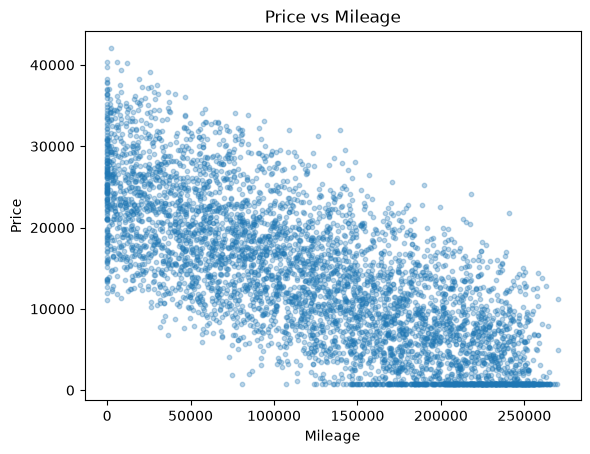

In [10]:
#Mileage vs Price
plt.scatter(df['Mileage'], df['Price'],alpha=0.3, s=10)
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Price vs Mileage')
plt.show()

In [11]:
df

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Toyota,Yaris,2019,2.7,90003,Diesel,Manual,11500
1,Nissan,Juke,2020,4.2,71865,Petrol,Manual,19530
2,Nissan,Juke,2013,4.3,159740,Petrol,Automatic,11270
3,Kia,Stonic,2011,3.5,178521,Petrol,Automatic,6330
4,Hyundai,i10,2021,1.7,64258,Petrol,Manual,10650
...,...,...,...,...,...,...,...,...
4995,Suzuki,Alto,2015,1.0,135214,Diesel,Automatic,800
4996,Toyota,Fortuner,2019,3.8,66994,Petrol,Manual,19870
4997,BMW,X1,2018,1.5,105024,Petrol,Automatic,19420
4998,Nissan,Patrol,2024,2.0,33303,Petrol,Manual,15950


In [12]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 7)
(1000, 7)


In [14]:
num_cols = [
    "Year",
    "Engine Size",
    "Mileage"
]

In [15]:
cat_cols = [
    "Make",
    "Model",
    "Fuel Type",
    "Transmission"
]

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_cols
        )
    ]
)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=100),

    "Lasso": Lasso(alpha=0.1),

    "ElasticNet": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        random_state=42
    )
}

In [25]:
predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2
5,Gradient Boosting,1299.937543,1641.862208,0.967668
2,Lasso,1401.405433,1843.813094,0.959226
0,Linear Regression,1401.691696,1844.163273,0.959210
4,Random Forest,1515.186050,1949.658284,0.954410
1,Ridge,1575.948316,2009.645975,0.951561
3,ElasticNet,1794.627855,2263.947584,0.938527


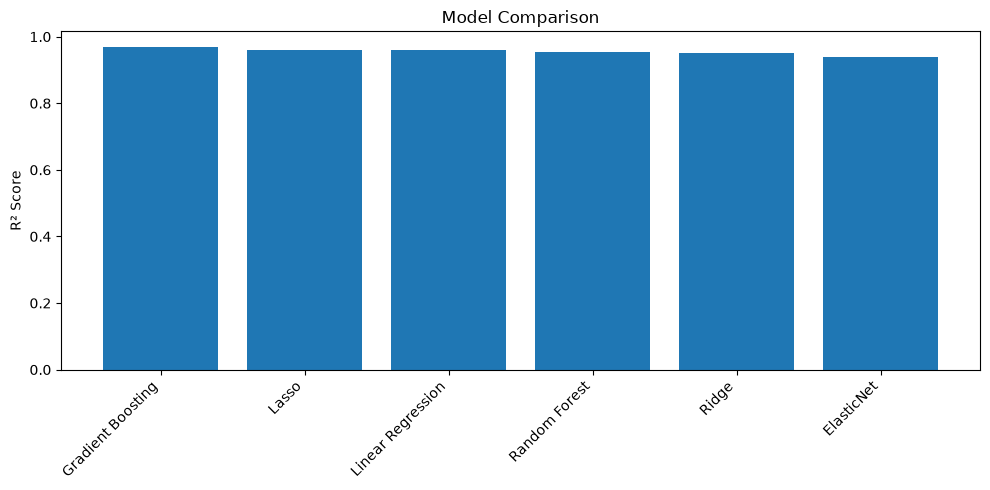

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("R² Score")
plt.title("Model Comparison")

plt.tight_layout()
plt.show()

In [28]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [29]:
y_pred_best = best_model.predict(X_test)

In [30]:
best_model_name = "Gradient Boosting"

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [31]:
y_pred_best = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_best)

final_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

final_r2 = r2_score(y_test, y_pred_best)

print("Gradient Boosting Performance")
print("--------------------------------")
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²  :", round(final_r2, 3))

Gradient Boosting Performance
--------------------------------
MAE : 1299.94
RMSE: 1641.86
R²  : 0.968


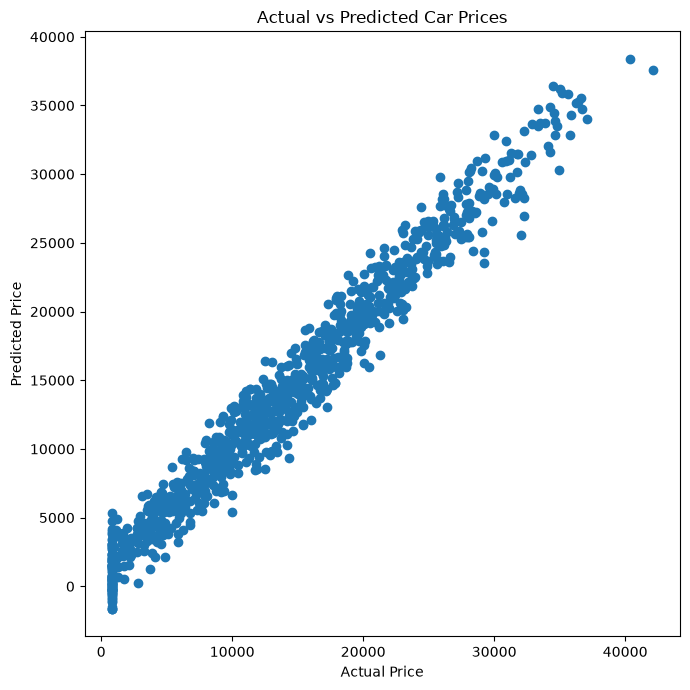

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_best
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.tight_layout()
plt.show()

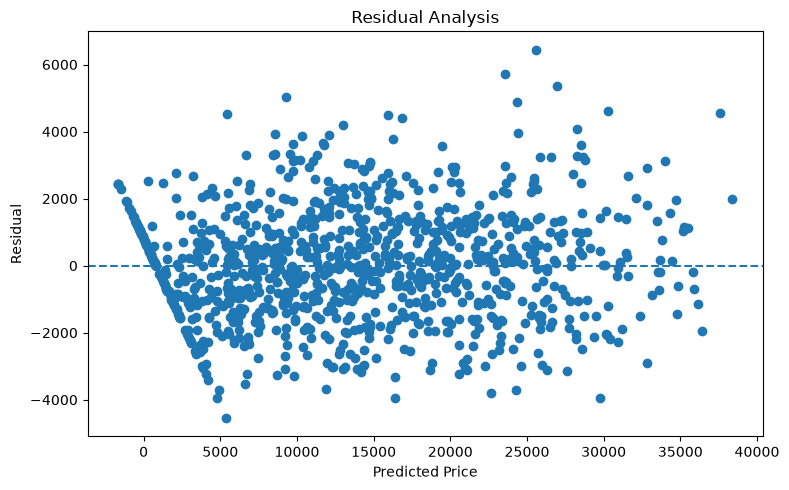

In [33]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_best,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("5-Fold CV R² Scores:")
print(cv_scores)

print(
    "Mean CV R²:",
    round(cv_scores.mean(), 3)
)

5-Fold CV R² Scores:
[0.96825752 0.96748367 0.96819337 0.96730595 0.96584488]
Mean CV R²: 0.967


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best CV R²:",
    round(grid_search.best_score_, 3)
)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV R²: 0.966


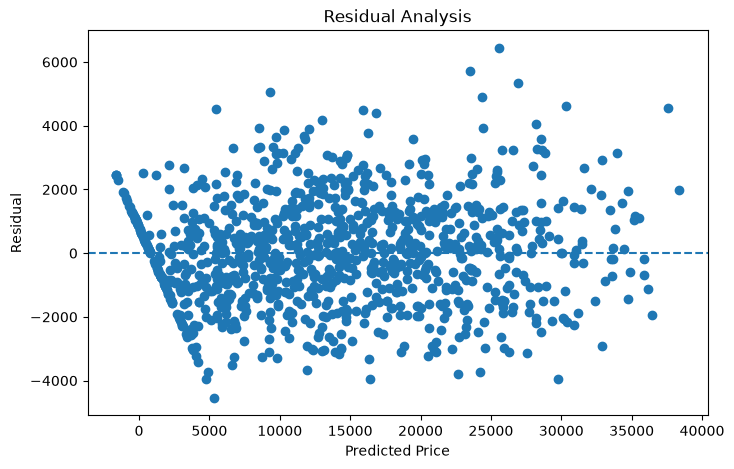

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_best,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.show()

In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² Scores: [0.96825752 0.96748367 0.96819337 0.96730595 0.96584488]
Mean CV R²: 0.9674170790993321


In [38]:
final_model = grid_search.best_estimator_

In [39]:
final_model = best_model

In [40]:
final_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("Final Model Performance")
print("-----------------------")
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²  :", round(final_r2, 3))

Final Model Performance
-----------------------
MAE : 1299.94
RMSE: 1641.86
R²  : 0.968


In [41]:
import joblib

joblib.dump(
    final_model,
    "car_price_prediction_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [42]:
loaded_model = joblib.load(
    "car_price_prediction_model.pkl"
)

test_prediction = loaded_model.predict(
    X_test
)

print("Model loaded successfully.")
print(
    "First 5 predictions:",
    test_prediction[:5]
)

Model loaded successfully.
First 5 predictions: [ 9908.69336407  1034.67477189  9868.4740839  11229.34572132
 26792.44259078]


In [43]:
print(sorted(df["Make"].unique()))
print(sorted(df["Model"].unique()))
print(sorted(df["Fuel Type"].unique()))
print(sorted(df["Transmission"].unique()))

['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Mercedes', 'Nissan', 'Suzuki', 'Toyota']
['1 Series', '3 Series', '5 Series', 'A-Class', 'A3', 'A4', 'A6', 'Accord', 'Altima', 'Alto', 'Baleno', 'C-Class', 'CR-V', 'Camry', 'Cerato', 'City', 'Civic', 'Corolla', 'Cultus', 'E-Class', 'Elantra', 'Escape', 'Explorer', 'Fiesta', 'Focus', 'Fortuner', 'GLA', 'GLC', 'Jazz', 'Juke', 'Mustang', 'Patrol', 'Picanto', 'Q3', 'Q5', 'RAV4', 'Santa Fe', 'Sonata', 'Sorento', 'Sportage', 'Stonic', 'Sunny', 'Swift', 'Tucson', 'Wagon R', 'X-Trail', 'X1', 'X5', 'Yaris', 'i10']
['Diesel', 'Electric', 'Hybrid', 'Petrol']
['Automatic', 'Manual']
